# Two days 2m temperature forecast using the ECMWF Open Data
The ECMWF provides a subset of its forecasts as open data. The data can be downloaded anonimously without setting up an account. The [ecmwf.opendata](https://github.com/ecmwf/ecmwf-opendata) Python package provides the method to access and download the data. The forecast are available for only one step, e.g. today at 12:00 and then adding 12 hours or a multiple of 12 hours for the nexts day. For example, a step of 36 hours for the forecast tomorrow at 12:00, or a step of 60 hours for the forecast two days from now at 12:00 . The data format is GRIB. Xarray can read the data if the [cgrib engine](https://github.com/ecmwf/cfgrib) is installed. Links to more info are in the references. The ECMWF makes [plots and charts](https://charts.ecmwf.int/) from weather data using [Metview](https://metview.readthedocs.io/en/latest/), a software platform for the analysis of weather data. In this notebook we use Xarray and Matplotlib. In the next sections of this notebook we will download the forecast of the 2m temperature for today, tomorrow at 12:00 (36 hours lead time) and in the next two days, (60 hours lead time). 

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy
from ecmwf.opendata import Client
import pygrib

We create an instance of the ECMWF client

In [2]:
client = Client("ecmwf", beta=False)

To ensure the stability of our systems and to preserve resources for our operational activities (network, compute, etc.), access to the open-data portal is limited to 500 simultaneous connections. This limit helps us guarantee reliable service for our operational users, especially during periods of high demand. For added reliability, the open-data is replicated across AWS, Azure, and Google Cloud. If you experience difficulties accessing the portal directly, you can also retrieve the data from these cloud platforms.


From the variables available we select the 2m temperature and the mean sea level pressure.

In [3]:
parameters = ['2t', 'msl']

Since we are going to call the service several times we define a function with the lead time as the only argument

In [5]:
def call_ecmwf(lead_time):
    '''
    This function calls the ECMWF Open Data service,
    write the GRIB file locally and returns its file 
    name.
    '''
    txt = str(lead_time)
    file_name = 'forecast-' + txt + '-t2m-msl.grib'
    client.retrieve(
        date=0,
        time=0,
        step=str(lead_time),
        stream="oper",
        type="fc",
        levtype="sfc",
        param=parameters,
        target=file_name
    )
    return file_name

We call the ECMWF service for a first forecast today at 12:00

In [6]:
forecast_12_data = call_ecmwf(12)

20260527000000-12h-oper-fc.grib2:   0%|          | 0.00/1.13M [00:00<?, ?B/s]

By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.


We load the data into Xarray. We can see from the description that the forecast is for today (time field) with a lead time (step) of 12 hours, that is today at 12:00. 

In [7]:
ds1 = xr.load_dataset(forecast_12_data.strip(), engine="cfgrib")
ds1

<xarray.Dataset> Size: 8MB
Dimensions:            (latitude: 721, longitude: 1440)
Coordinates:
    time               datetime64[ns] 8B 2026-05-27
    step               timedelta64[ns] 8B 12:00:00
    heightAboveGround  float64 8B 2.0
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB -180.0 -179.8 ... 179.5 179.8
    valid_time         datetime64[ns] 8B 2026-05-27T12:00:00
    meanSea            float64 8B 0.0
Data variables:
    t2m                (latitude, longitude) float32 4MB 264.0 264.0 ... 227.5
    msl                (latitude, longitude) float32 4MB 1.014e+05 ... 1.005e+05
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-27T15:54 GRIB to CDM+CF via cfgrib-0.9.1...

We call the ECMWF service a 2nd time for the t2m and msl forecast for tomorrow at the same time, 12:00.

In [8]:
forecast_36_data = call_ecmwf(36)

20260527000000-36h-oper-fc.grib2:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

We can see from the dataset the step field now is 1 day forecast at 12:00

In [9]:
ds2 = xr.load_dataset(forecast_36_data, engine="cfgrib")
ds2

<xarray.Dataset> Size: 8MB
Dimensions:            (latitude: 721, longitude: 1440)
Coordinates:
    time               datetime64[ns] 8B 2026-05-27
    step               timedelta64[ns] 8B 1 days 12:00:00
    heightAboveGround  float64 8B 2.0
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB -180.0 -179.8 ... 179.5 179.8
    valid_time         datetime64[ns] 8B 2026-05-28T12:00:00
    meanSea            float64 8B 0.0
Data variables:
    t2m                (latitude, longitude) float32 4MB 262.9 262.9 ... 227.9
    msl                (latitude, longitude) float32 4MB 1.015e+05 ... 1.001e+05
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-27T15:55 GRIB to CDM+CF via cfgrib-0.9.1...

Finally, we call the ECMWF service a third time for a forecast two days ahead at the same time 12:00

In [10]:
forecast_60_data = call_ecmwf(60)

20260527000000-60h-oper-fc.grib2:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

We can see from the dataset the step field now is 2 day forecast at 12:00, so two days from now at 12:00

In [11]:
ds3 = xr.load_dataset(forecast_60_data, engine="cfgrib")
ds3

<xarray.Dataset> Size: 8MB
Dimensions:            (latitude: 721, longitude: 1440)
Coordinates:
    time               datetime64[ns] 8B 2026-05-27
    step               timedelta64[ns] 8B 2 days 12:00:00
    heightAboveGround  float64 8B 2.0
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB -180.0 -179.8 ... 179.5 179.8
    valid_time         datetime64[ns] 8B 2026-05-29T12:00:00
    meanSea            float64 8B 0.0
Data variables:
    t2m                (latitude, longitude) float32 4MB 269.5 269.5 ... 222.8
    msl                (latitude, longitude) float32 4MB 1.003e+05 ... 9.982e+04
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-27T15:55 GRIB to CDM+CF via cfgrib-0.9.1...

We will plot the 2m temperature datasets several times so better to define a function

In [13]:
def plot_t2m_forecast(xr_dataset, colorbar=True):
    plt.figure(figsize=(20,8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.gridlines(draw_labels=True, linestyle='--')
    ax.add_feature(cartopy.feature.OCEAN)
    ax.add_feature(cartopy.feature.LAND, edgecolor='black')
    ax.add_feature(cartopy.feature.LAKES, edgecolor='black')
    ax.add_feature(cartopy.feature.RIVERS)
    ax.coastlines()
    xr_dataset.plot(ax=ax, add_colorbar=colorbar, cmap='jet')

## 2m surface temperature forecasts
The 2m temperature forecast (t2m) dataset returned by the service covers the entire planet but we will focus over the european region.

In [14]:
bb_north = 60.0
bb_south = 35.0
bb_west = -10.0
bb_east = 40.0

We plot the 2m temperature forecast for today at 12:00

In [16]:
temperature2m_1 = ds1['t2m'].sel(latitude = slice(bb_north, bb_south), 
                                 longitude = slice(bb_west, bb_east))

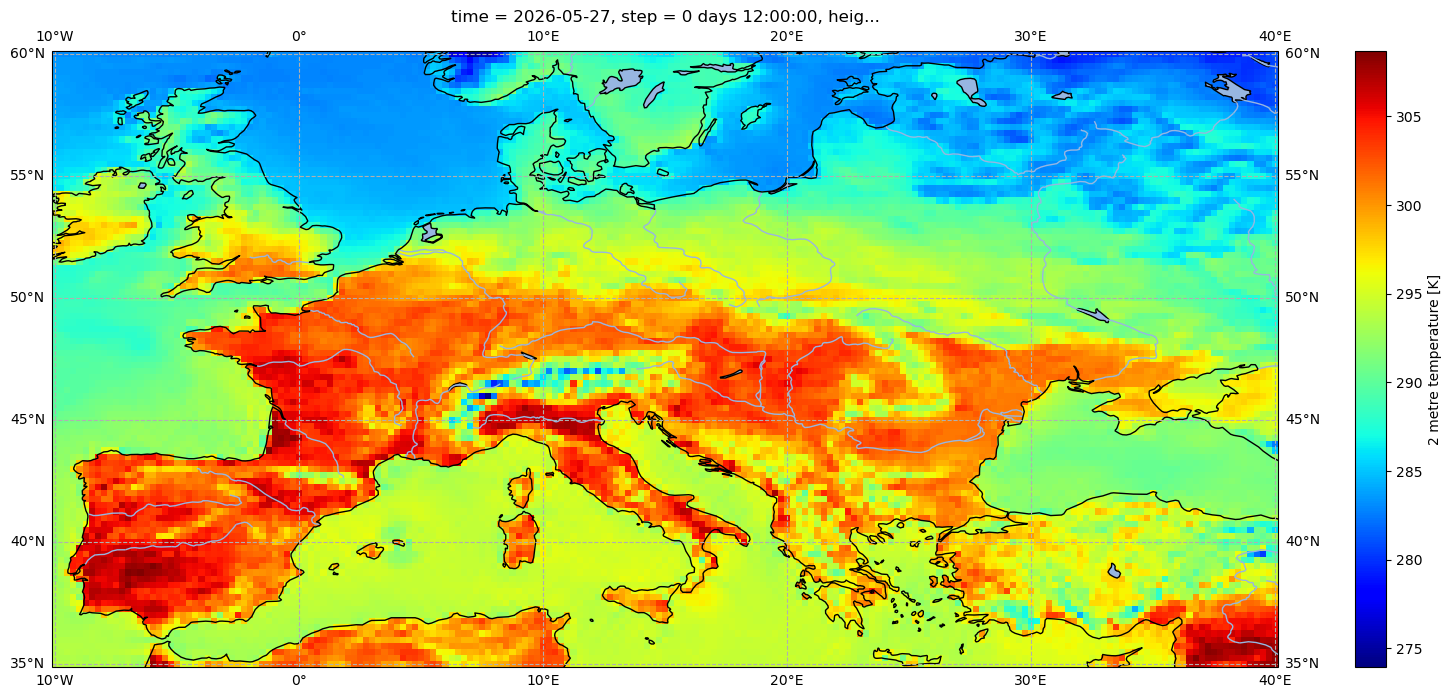

In [17]:
plot_t2m_forecast(temperature2m_1)

We plot the forecast for tomorrow at 12:00

In [18]:
temperature2m_2 = ds2['t2m'].sel(latitude = slice(bb_north, bb_south), 
                                 longitude = slice(bb_west, bb_east))

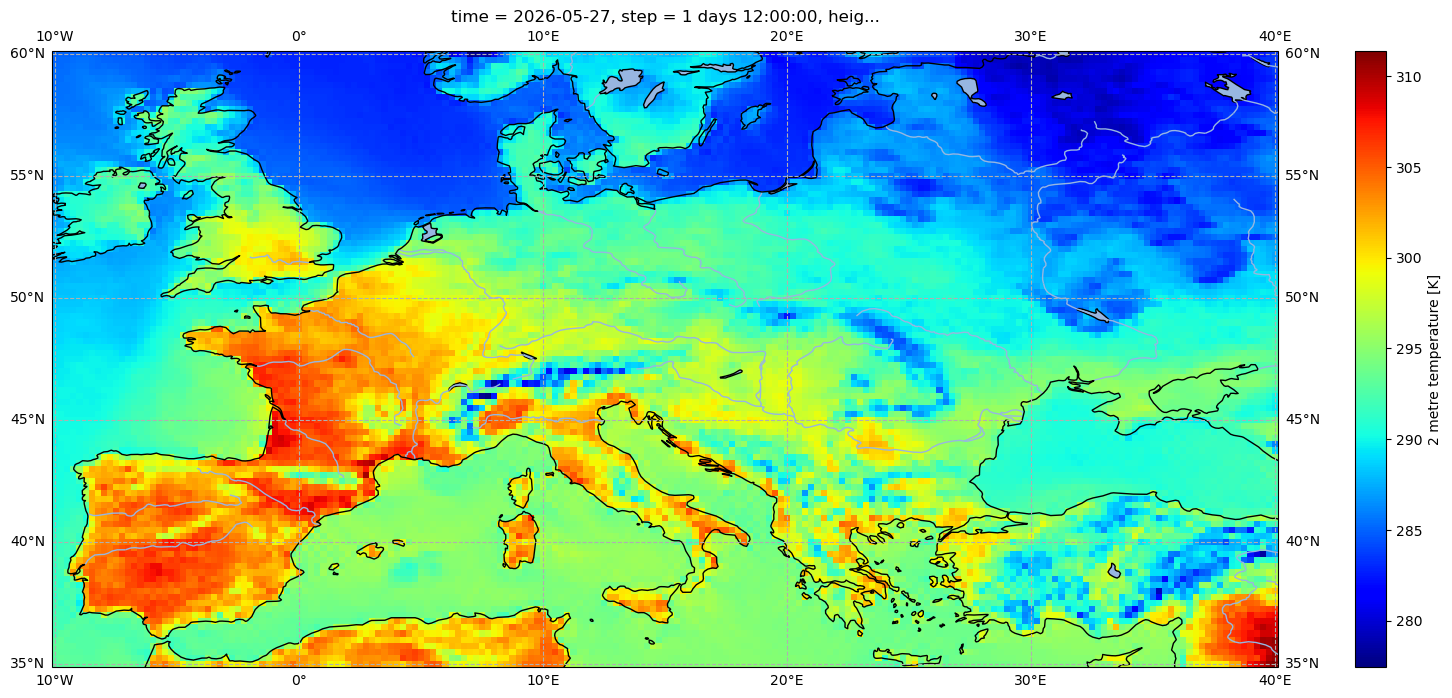

In [19]:
plot_t2m_forecast(temperature2m_2)

And finally the plot for the 2m temperature forecast two days from now at 12:00

In [20]:
temperature2m_3 = ds3['t2m'].sel(latitude = slice(bb_north, bb_south), 
                                 longitude = slice(bb_west, bb_east))

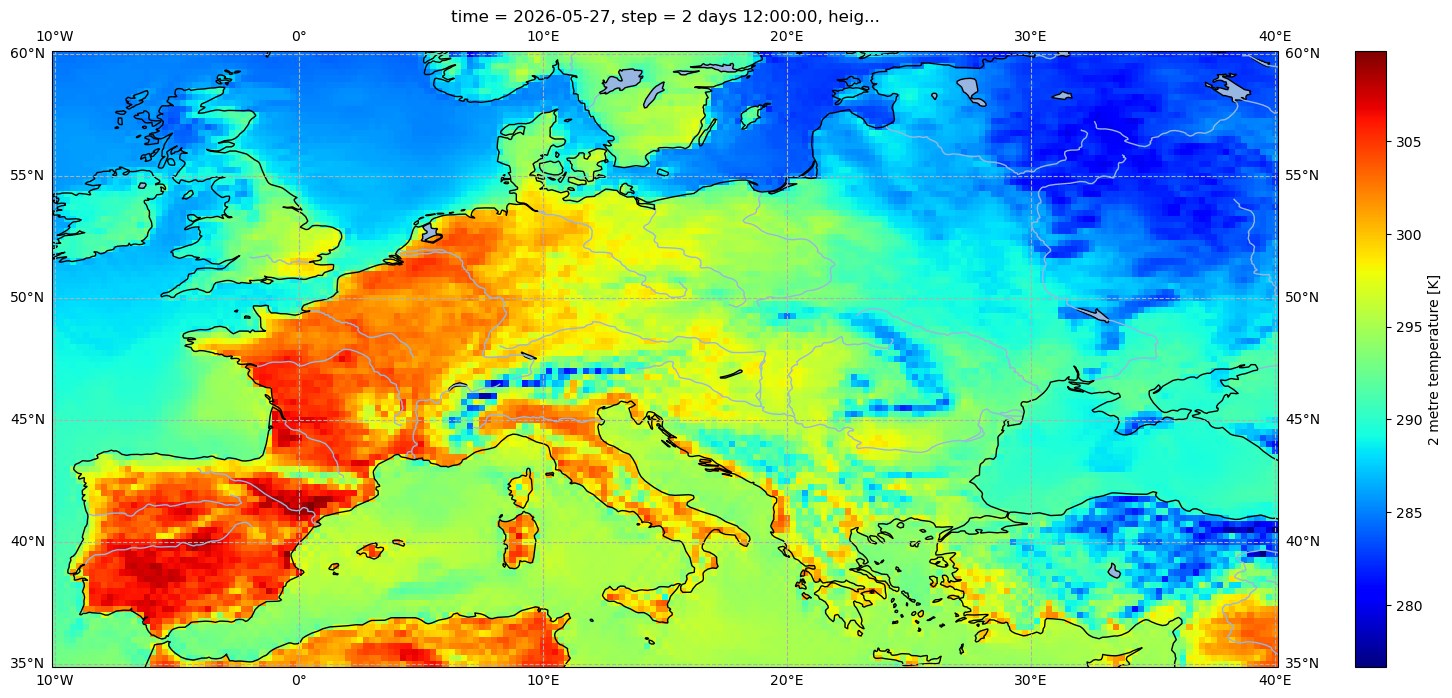

In [21]:
plot_t2m_forecast(temperature2m_3)

## Is the temperature going to increase or decrease ?
Looking at the maps it seems that the temperature will decrease tomorrow over most of Eastern Europe, Italy and Turkey and slightly increase again the day after. But we can simply make the difference between tomorrow and today and then between tomorrow and 2 days from now to have a better picture of the weather dynamic. 

In [22]:
t2m_1_2_diff =  temperature2m_2 - temperature2m_1

The blue areas is where the temperature will decrease tomorrow. Orange and yellow is where it will increase. The mean difference will be -1 °C

In [23]:
print('Mean 2m temperature difference: {:.2f} °C'.format(t2m_1_2_diff.mean().values))

Mean 2m temperature difference: -1.06 °C


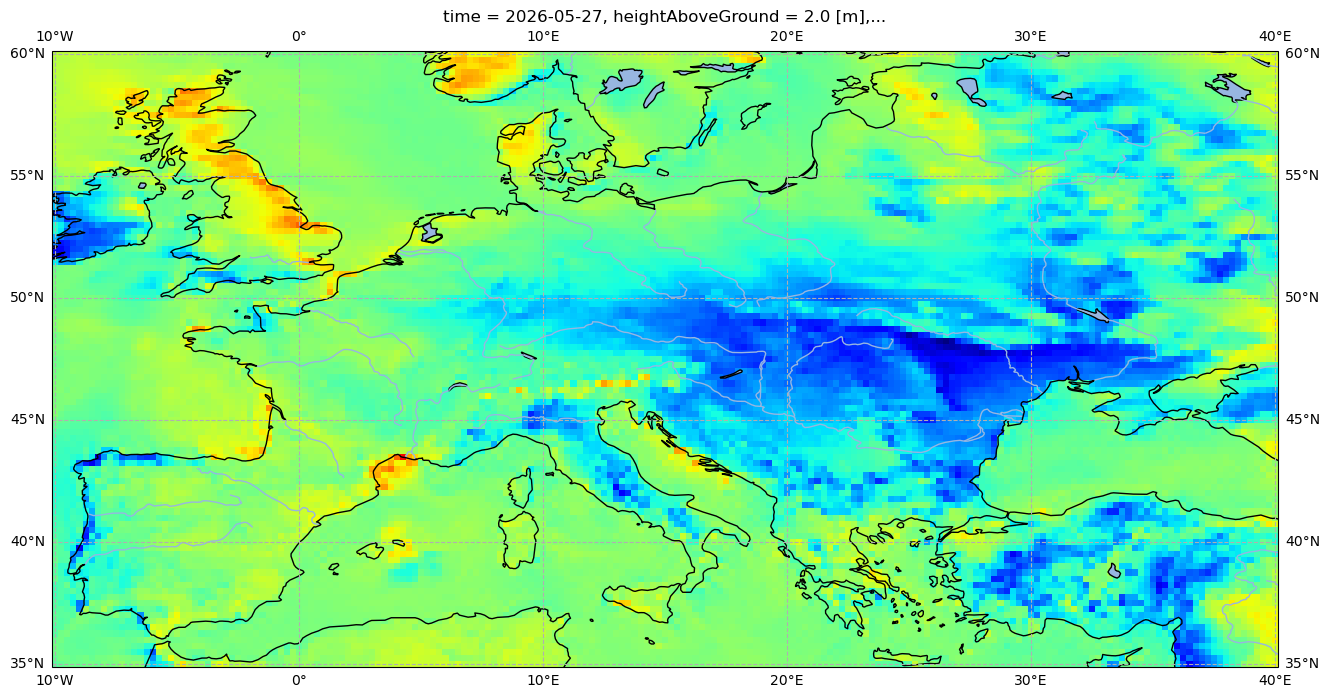

In [24]:
plot_t2m_forecast(t2m_1_2_diff, colorbar=False)

In the next two days we should have on average the same temperature like tomorrow with the exception of northern Germany, Belgium and Nederland. 

In [25]:
t2m_2_3_diff =  temperature2m_3 - temperature2m_2

In [26]:
print('Mean 2m temperature difference: {:.2f} °C'.format(t2m_2_3_diff.mean().values))

Mean 2m temperature difference: -0.02 °C


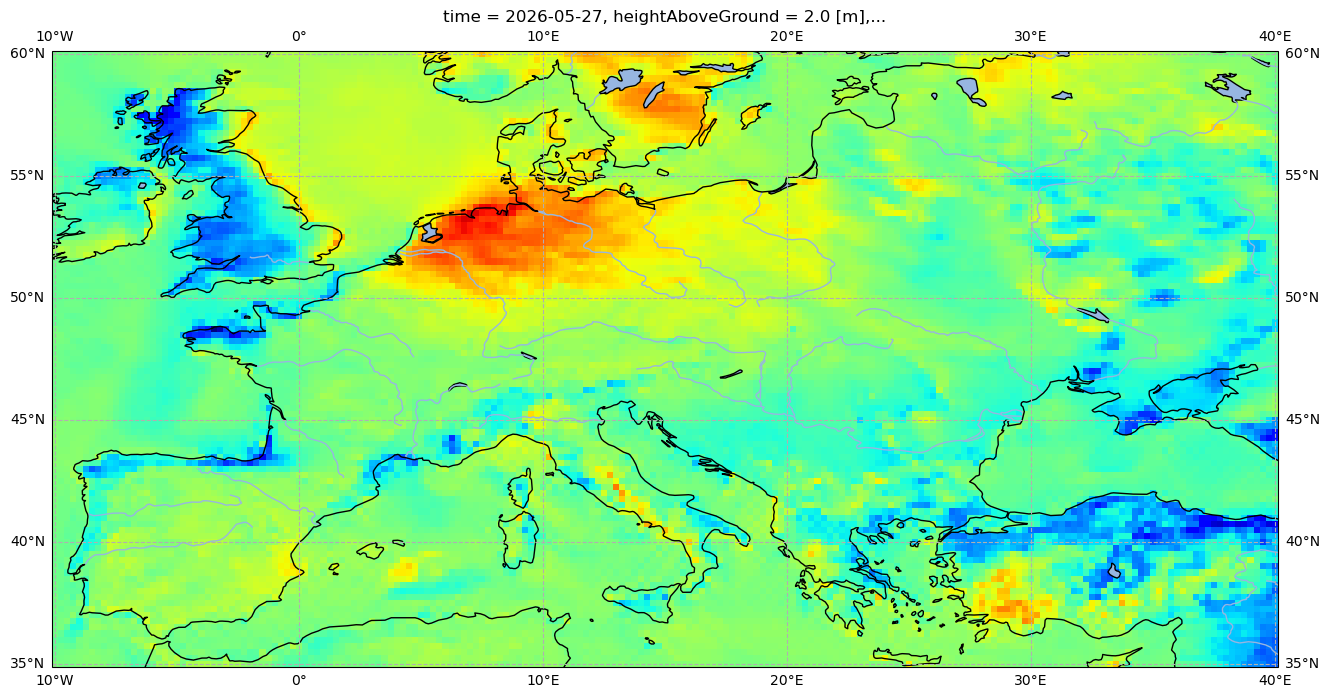

In [27]:
plot_t2m_forecast(t2m_2_3_diff, colorbar=False)

## Mean sea level pressure
Many other variables are available from the ECMWF Open Data service, one of these is the mean sea level pressure (msl). We will not go into the details but it would be interesting to plot the difference of the msl for the same days to see whether and where the pressure is going to change. We define another function to draw the contour plot of the pressure field.

In [28]:
def plot_msl(xr_dataset):
    plt.figure(figsize=(20,10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.gridlines(draw_labels=True, linestyle='--')
    ax.add_feature(cartopy.feature.OCEAN)
    ax.add_feature(cartopy.feature.LAND, edgecolor='black')
    ax.add_feature(cartopy.feature.LAKES, edgecolor='black')
    ax.add_feature(cartopy.feature.RIVERS)
    ax.coastlines()
    xr_dataset.plot.contour(ax=ax, add_colorbar=False, add_labels=True)

In [29]:
mean_sl_pressure_1 = ds1['msl'].sel(latitude = slice(bb_north, bb_south), 
                                 longitude = slice(bb_west, bb_east))

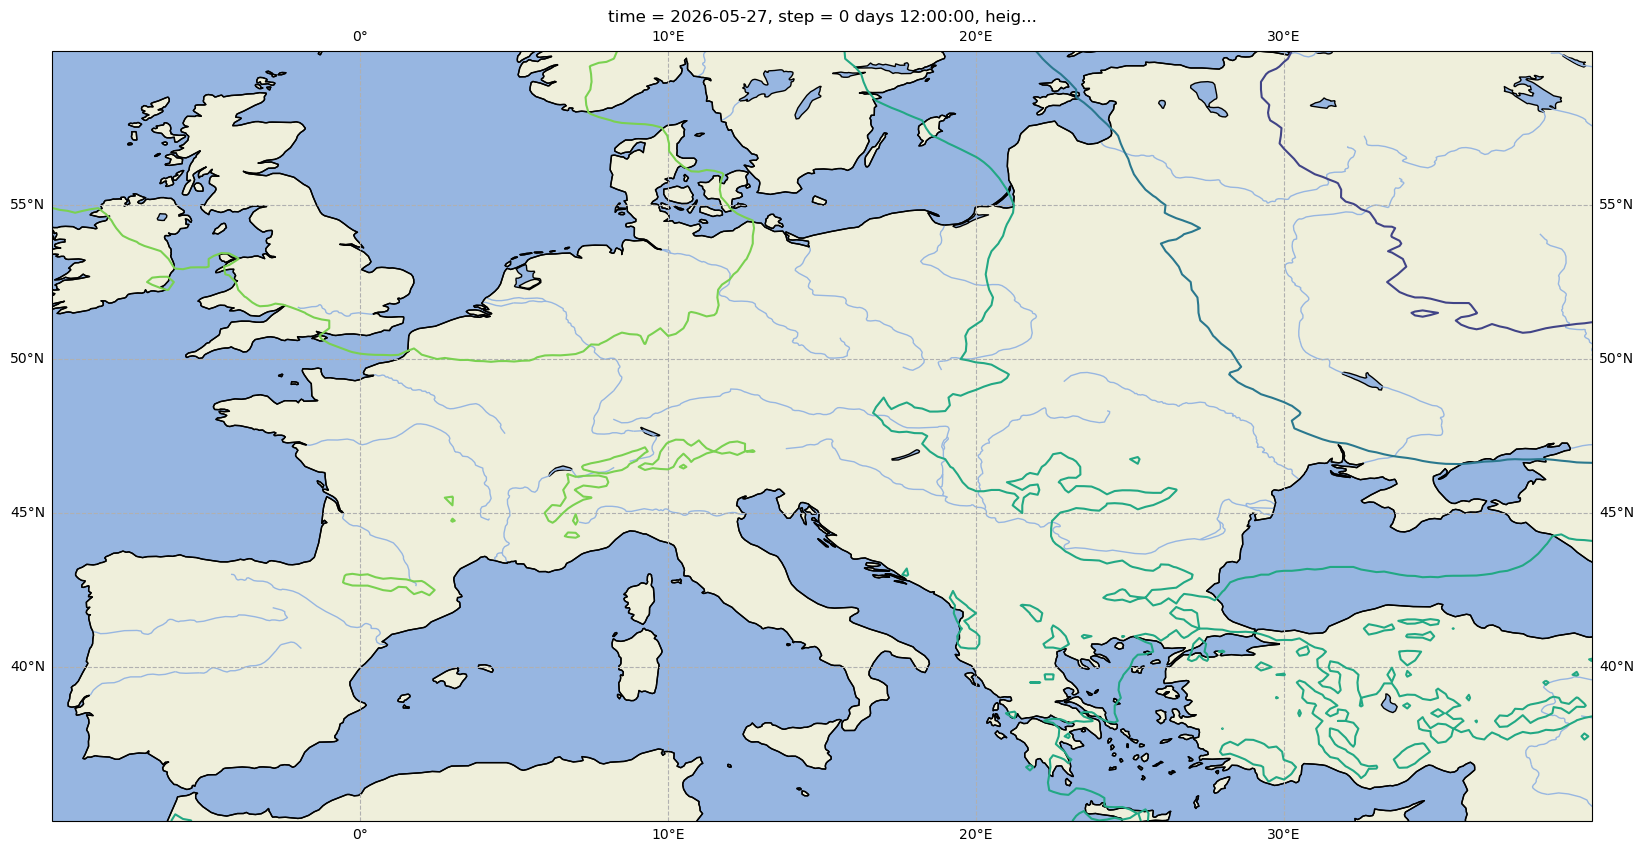

In [30]:
plot_msl(mean_sl_pressure_1)

## References
* [ECMWF Open Data](https://www.ecmwf.int/en/forecasts/datasets/open-data)